## *Case Study*
###### Conducted by: Gonzalo Martinez Ruiz 
###### Date: 06/05/2026
-----


# <b>*Scenario:*</b>

Senior leadership has asked the Data Solutions Team team to evaluate whether current spend levels are efficient and optimally allocated, and to provide a data-backed recommendation for future budget distribution.
Mark is running a regional acquisition campaign across multiple regions to drive new acquisitions per location . Media spend is allocated monthly at the regional level, and performance is tracked using metrics such as total spend, total acquisitions, average Cost Per Acquisition (CPA), and number of active locations in each region.
The current budgeting approach has evolved organically over time and is largely based on historical allocations rather than a formal data-driven optimization process.
You have been given a historical dataset summarizing performance by region, month, date.

&emsp;

*Questions to Answer:*

1. *Determine whether performance differences across regions are statistically significant.*
2. *Fit a regression forecasting "Acquisitions" for the next month across all regions. What problems did you encounter and how could they be resolved?*
3. *Design an experiment to measure the impact of incremental budget. What is your hypothesis and how would you test it?*
4. *Is lower CPA always indicative of better performance? The current target is  $30 for the previous years CPA.*
5. *Are some regions potentially underfunded or overfunded relative to their opportunity?*
6. *How should leadership think about reallocating budget if total spend remains flat?* 

&emsp;

----

In [522]:
#Loading Data Packages to be used in the analysis

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [523]:
# Loading Data 

df1 = pd.read_csv(r"C:\Users\gonzalo.martinezruiz\OneDrive - OneWorkplace\Desktop\Data for Case Study.csv")
df1.head(10)

,Date,Month,Region,Location Count,Spend,AVG Spend Per Location,Acquisitions,AVG Acquisitions Per Location,AVG Cost Per Acquisition
0,1/1/2025,2025 - 01,REGION 06,1,$732,732,12,12,61
1,1/1/2025,2025 - 01,REGION 07,1,$798,798,20,20,40
2,1/1/2025,2025 - 01,REGION 08,2,$923,462,13,7,71
3,1/1/2025,2025 - 01,REGION 09,1,$712,712,13,13,55
4,1/1/2025,2025 - 01,REGION 10,1,$473,473,7,7,68
5,1/1/2025,2025 - 01,REGION 11,33,"$19,252",583,397,12,48
6,1/1/2025,2025 - 01,REGION 12,12,"$5,429",452,145,12,37
7,1/1/2025,2025 - 01,REGION 13,4,"$1,335",334,38,10,35
8,1/1/2025,2025 - 01,REGION 14,4,"$1,856",464,46,12,40
9,1/1/2025,2025 - 01,REGION 15,7,"$3,041",434,70,10,43


-----

## *Data Cleaning*

In [524]:
#Data Cleaning and Preprocessing

df1.info() #Data Types and Non-Null Counts
print("-" * 50)
df1.describe() # Summary Statistics

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25397 entries, 0 to 25396
Data columns (total 9 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Date                             25397 non-null  object
 1   Month                            25397 non-null  object
 2   Region                           25397 non-null  object
 3    Location Count                  25397 non-null  int64 
 4    Spend                           25397 non-null  object
 5    AVG Spend Per Location          25397 non-null  object
 6    Acquisitions                    25397 non-null  object
 7    AVG Acquisitions Per Location   25397 non-null  object
 8    AVG Cost Per Acquisition        25301 non-null  object
dtypes: int64(1), object(8)
memory usage: 1.7+ MB
--------------------------------------------------


,Location Count
count,25397.000000
mean,9.797811
std,12.702564
min,1.000000
25%,2.000000
50%,4.000000
75%,14.000000
max,70.000000


In [525]:
#Identifying Missing Values
df1.isnull().sum() 

Date                                0
Month                               0
Region                              0
 Location Count                     0
 Spend                              0
 AVG Spend Per Location             0
 Acquisitions                       0
 AVG Acquisitions Per Location      0
 AVG Cost Per Acquisition          96
dtype: int64

----
### ***Key Issues Identified***
After exploring the data through both Excel and in this environment, there are major cleaning problems that will affect every answer

- Any dollar sign, commas, and spaces in numeric fields change the data type into strings
- There are missing values ("$-",-")
- There are outliers (e.g, Region 66 has a massive spend spike with extreme CPA values)
- There is also mixed granularity in the data, regions vary in size a lot which can grant location count bias)

In [526]:
# Stripping spaces in column names
df1.columns = df1.columns.str.strip()

# Converting columns to numeric
cols_to_clean = ['Spend', 'AVG Spend Per Location', 'Acquisitions', 
                 'AVG Acquisitions Per Location', 'AVG Cost Per Acquisition']

for col in cols_to_clean:
    df1[col] = (
        df1[col]
        .astype(str)
        .str.replace('$', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.strip()
        .replace('-', np.nan)
    )
    df1[col] = pd.to_numeric(df1[col], errors='coerce')

# dropping missing / bad rows for modeling
df_clean = df1.dropna(subset=['Spend','Acquisitions','AVG Cost Per Acquisition'])

df_clean.head(10)

# Data is now clean and ready for analysis

,Date,Month,Region,Location Count,Spend,AVG Spend Per Location,Acquisitions,AVG Acquisitions Per Location,AVG Cost Per Acquisition
0,1/1/2025,2025 - 01,REGION 06,1,732.0,732.0,12.0,12.0,61.0
1,1/1/2025,2025 - 01,REGION 07,1,798.0,798.0,20.0,20.0,40.0
2,1/1/2025,2025 - 01,REGION 08,2,923.0,462.0,13.0,7.0,71.0
3,1/1/2025,2025 - 01,REGION 09,1,712.0,712.0,13.0,13.0,55.0
4,1/1/2025,2025 - 01,REGION 10,1,473.0,473.0,7.0,7.0,68.0
5,1/1/2025,2025 - 01,REGION 11,33,19252.0,583.0,397.0,12.0,48.0
6,1/1/2025,2025 - 01,REGION 12,12,5429.0,452.0,145.0,12.0,37.0
7,1/1/2025,2025 - 01,REGION 13,4,1335.0,334.0,38.0,10.0,35.0
8,1/1/2025,2025 - 01,REGION 14,4,1856.0,464.0,46.0,12.0,40.0
9,1/1/2025,2025 - 01,REGION 15,7,3041.0,434.0,70.0,10.0,43.0


&emsp;

----

# ***Question 1: Are Performance differences across regions statistically significant?***

**Statistical Signifigance for dummies:** Statistical significance indicates that a result observed in data is highly unlikely to have occurred by random chance

Approach: 
- Use ANOVA to compare averages across many regions
- Metric being used: Acquisitions Per Location or Cost Per Acquisition (CPA)

An ANOVA test was conducted to evaluate whether performance differences across regions are statistically significant. 

**Interpretation**

If p < 0.05 → Yes, significant differences exist
Given the dataset:

- Huge variance in CPA (from $10 - over $300)
- Large performance dispersion across regions

**<u>Hypothesis: Differences will almost certainly be statistically significant.</u>**

**Null Hypothesis (H₀)** = The mean performance is the same across all regions and the data we see is just random noise(doubt it).

**Alternative Hypothesis (H₁)** = The mean performance varies significantly between regions and any variation we see is meaningful.

In [527]:
#ANOVA Test to compare the means of 'AVG Cost Per Acquisition' across different 'Region' groups

groups = [g['AVG Cost Per Acquisition'].dropna().values 
          for _, g in df_clean.groupby('Region')]


f_stat, p_val = stats.f_oneway(*groups)

print(f_stat, p_val)

20.75625785114189 2.176404005060631e-266


<u>**Interpretation**</u>

If p < 0.05  then Yes, significant differences exist
Given the dataset:

<u>**F-statistic:**</u> 20.76

<u>**p-value:**</u> 2.18 × 10⁻²⁶⁶ (essentially zero and is < 0.5)

This tells us the following:
- Data has large variances in CPA
- This is seen in dispersion across regions for both CPA/acquisitions

<u>**Result/Conclusion:**</u> 

The results (F = 20.76, p < 0.001) indicate that regional performance differences are not due to random variation but show real differences. This tells us that regions are operating differently due to different demand conditions

<u>**Insight:**</u>

Regional Performance is structurally different, this is not random noise. **<u>The perfromance differences across regions are statistically significant.</u>**

&emsp;

----

&emsp;
# ***Question 2: Fit a regression forecasting "Acquisitions" for the next month across all regions. What problems did you encounter and how could they be resolved?***
&emsp;



### <b>*Attempt 1 - Model is anchored to the full-year trend + average yearly level, with weekly seasonality layered on top*</b>

The question implies we are forecasting for January 2025 and Acquisitions for that month across all the regions. My approach here was to consolidate the result for January 2025.

&emsp;

C:\Users\gonzalo.martinezruiz\AppData\Local\Temp\ipykernel_37136\3294681476.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Date'] = pd.to_datetime(df_clean['Date'])


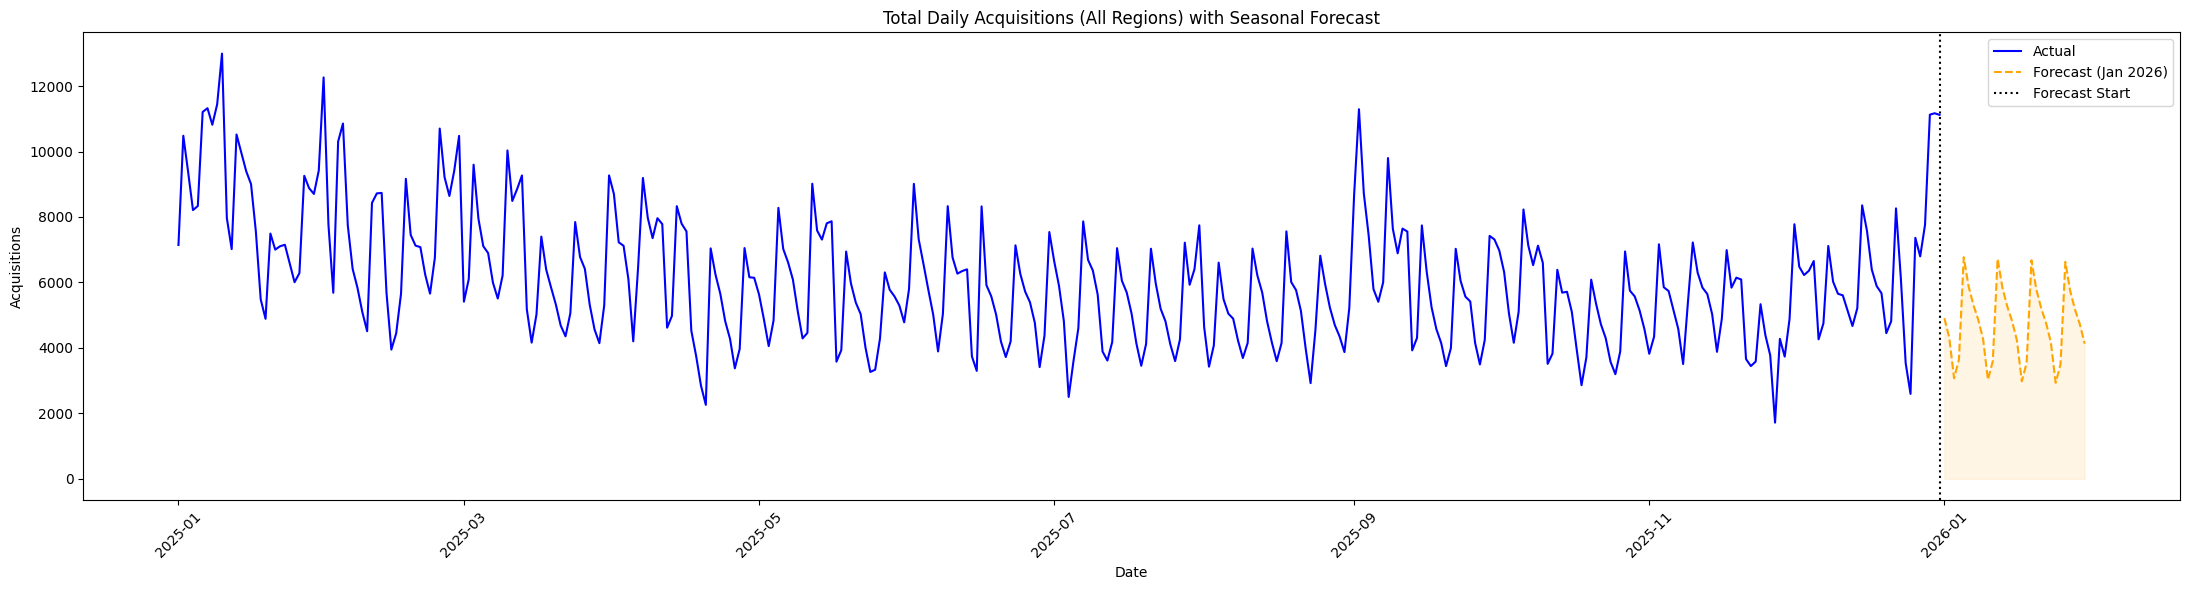


===== Early Model Comparison (Trend + Day-of-Week) =====



C:\Users\gonzalo.martinezruiz\AppData\Local\Temp\ipykernel_37136\3294681476.py:148: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-47.09%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  comparison.loc[2, 'Value'] = f"{((forecast_total - jan_2025_total) / jan_2025_total):+.2%}"


,Metric,Value
0,Jan 2025 Actual,269290.0
1,Jan 2026 Forecast (Trend + Weekly Model),142482.0
2,YoY % Variance,-47.09%


In [528]:
 
# 1. Prep data (aggregate)
 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure Date is datetime
df_clean['Date'] = pd.to_datetime(df_clean['Date'])

# Aggregate to total daily acquisitions
df_daily = df_clean.groupby('Date')['Acquisitions'].sum().reset_index()

 
# 2. Feature engineering
 

# Time index
df_daily['t'] = range(len(df_daily))

# Day of week (captures weekly seasonality)
df_daily['day_of_week'] = df_daily['Date'].dt.dayofweek

# One-hot encode day of week
df_model = pd.get_dummies(df_daily, columns=['day_of_week'], drop_first=True)

 
# 3. Train model
 

from sklearn.linear_model import LinearRegression

X = df_model.drop(columns=['Date','Acquisitions'])
y = df_model['Acquisitions']

model = LinearRegression()
model.fit(X, y)

 
# 4. Create future dates (Jan 2026)
 

last_date = df_daily['Date'].max()

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=30
)

future_df = pd.DataFrame({'Date': future_dates})

# Add features
future_df['t'] = range(len(df_model), len(df_model)+30)
future_df['day_of_week'] = future_df['Date'].dt.dayofweek

# One-hot encode
future_df = pd.get_dummies(future_df, columns=['day_of_week'], drop_first=True)

# Align columns to match training data
future_df = future_df.reindex(columns=X.columns, fill_value=0)

 
# 5. Predict
 

forecast = model.predict(future_df)

forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Acquisitions': forecast
})

 
# 6. Visualization
 

plt.figure(figsize=(22,6))

# Actuals
sns.lineplot(data=df_daily,
             x='Date',
             y='Acquisitions',
             label='Actual',
             color='blue')

# Forecast (with seasonality)
sns.lineplot(data=forecast_df,
             x='Date',
             y='Acquisitions',
             label='Forecast (Jan 2026)',
             color='orange',
             linestyle='--')

# Split line
plt.axvline(x=last_date,
            color='black',
            linestyle=':',
            label='Forecast Start')

# Optional: shade forecast area
plt.fill_between(forecast_df['Date'],
                 forecast_df['Acquisitions'],
                 alpha=0.1,
                 color='orange')

plt.title('Total Daily Acquisitions (All Regions) with Seasonal Forecast')
plt.xlabel('Date')
plt.ylabel('Acquisitions')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()

plt.show()

 
# 7. January 2025 ACTUAL
 

jan_2025_data = df_daily[
    (df_daily['Date'].dt.year == 2025) &
    (df_daily['Date'].dt.month == 1)
]

jan_2025_total = jan_2025_data['Acquisitions'].sum()

 
# 8. January 2026 FORECAST
 

forecast_total = forecast_df['Acquisitions'].sum()

 
# 9. Build comparison table
 

comparison = pd.DataFrame({
    'Metric': ['Jan 2025 Actual',
               'Jan 2026 Forecast (Trend + Weekly Model)',
               'YoY % Variance'],
    'Value': [
        int(round(jan_2025_total, 0)),
        int(round(forecast_total, 0)),
        (forecast_total - jan_2025_total) / jan_2025_total
    ]
})

comparison.loc[2, 'Value'] = f"{((forecast_total - jan_2025_total) / jan_2025_total):+.2%}"

print("\n===== Early Model Comparison (Trend + Day-of-Week) =====\n")
display(comparison)

## <b>*Result*</b>

The trend-based model anchored predictions to the declining trajectory observed throughout the year, resulting in a forecast that closely resembles December performance rather than the elevated January peak. This led to a substantial underestimation of acquisitions and a large negative YoY variance.

&emsp;

----

&emsp;

###  <b>*Attempt 2 - Use the last 90 days worth of data to predict January*</b>

#### This attempted to mimic future acquisitions and what they looked like in recent performance, adjusted for weekday patterns

&emsp;

C:\Users\gonzalo.martinezruiz\AppData\Local\Temp\ipykernel_37136\3473140643.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Date'] = pd.to_datetime(df_clean['Date'])


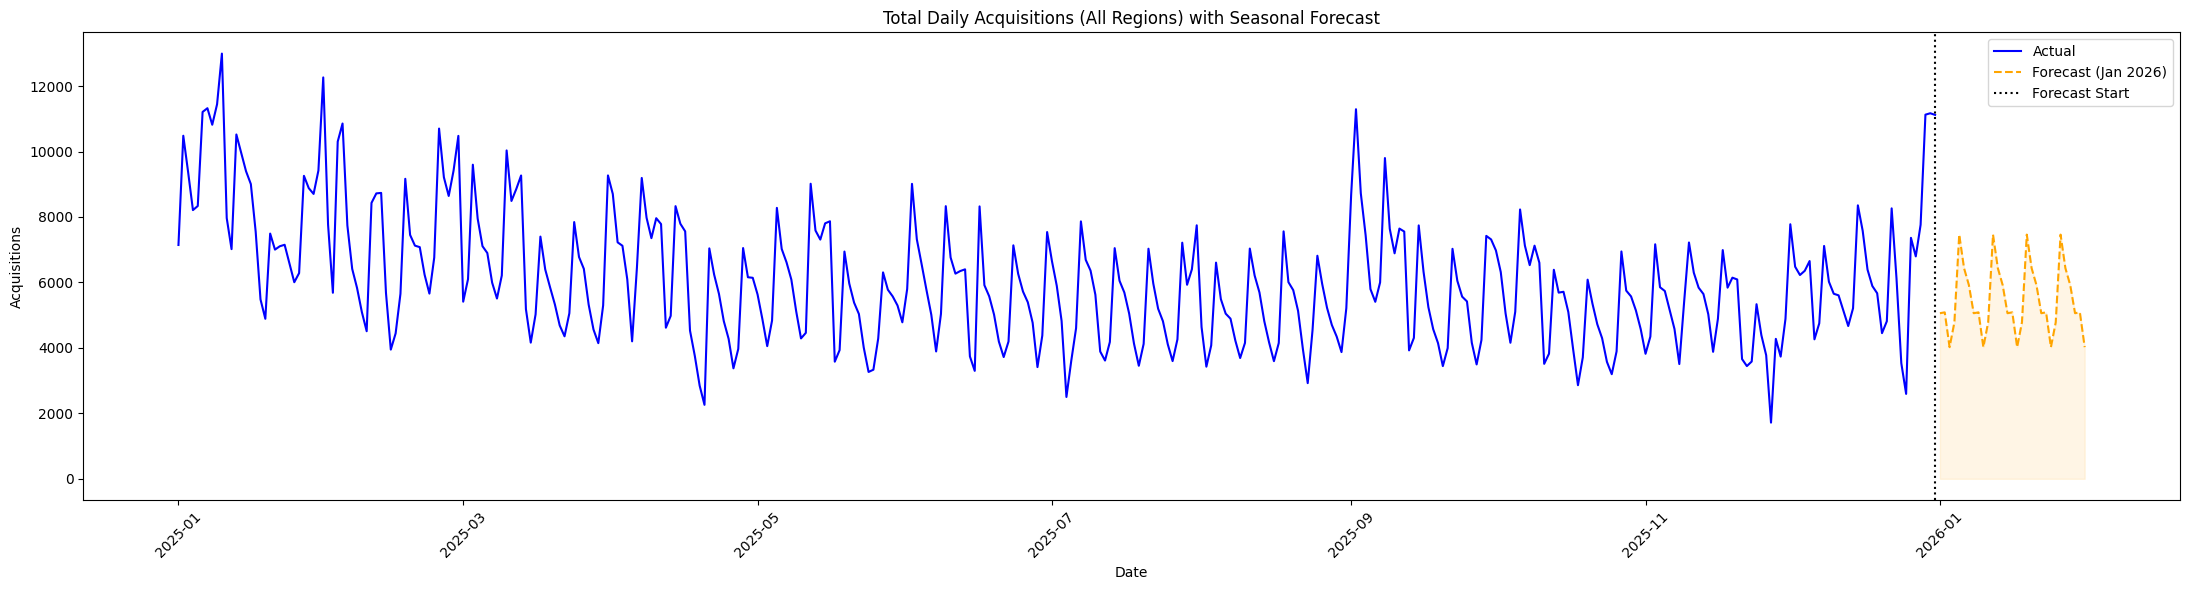

C:\Users\gonzalo.martinezruiz\AppData\Local\Temp\ipykernel_37136\3473140643.py:132: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-37.15%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  comparison.loc[2, 'Value'] = f"{((forecast_total - jan_2025_total) / jan_2025_total):+.2%}"


,Metric,Value
0,Jan 2025 Actual,269290.0
1,Jan 2026 Forecast,169261.0
2,YoY % Variance,-37.15%


In [529]:
# 1. Prep data (aggregate)


df_clean['Date'] = pd.to_datetime(df_clean['Date'])
df_daily = df_clean.groupby('Date')['Acquisitions'].sum().reset_index()


# 2. USE RECENT DATA ONLY (last 90 days)


df_recent = df_daily.tail(90).copy()


# 3. Feature engineering (seasonality)


df_recent['day_of_week'] = df_recent['Date'].dt.dayofweek

df_model = pd.get_dummies(df_recent, columns=['day_of_week'], drop_first=True)


# 4. Train model (NO TREND)


X = df_model.drop(columns=['Date','Acquisitions'])
y = df_model['Acquisitions']

model = LinearRegression()
model.fit(X, y)


# 5. Creating FULL Jan 2026 forecast


future_dates = pd.date_range(
    start='2026-01-01',
    end='2026-01-31'
)

future_df = pd.DataFrame({'Date': future_dates})

# Add seasonality features
future_df['day_of_week'] = future_df['Date'].dt.dayofweek

future_df = pd.get_dummies(future_df, columns=['day_of_week'], drop_first=True)

# Align columns
future_df = future_df.reindex(columns=X.columns, fill_value=0)


# 6. Predicting


forecast = model.predict(future_df)

forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Acquisitions': forecast
})

# Prevent negative predictions
forecast_df['Acquisitions'] = forecast_df['Acquisitions'].clip(lower=0)

# 7. Visualization


last_date = df_daily['Date'].max()

plt.figure(figsize=(22,6))

# Actual
sns.lineplot(data=df_daily,
             x='Date',
             y='Acquisitions',
             label='Actual',
             color='blue')

# Forecast
sns.lineplot(data=forecast_df,
             x='Date',
             y='Acquisitions',
             label='Forecast (Jan 2026)',
             color='orange',
             linestyle='--')

# Split
plt.axvline(x=last_date,
            color='black',
            linestyle=':',
            label='Forecast Start')

# Shading
plt.fill_between(forecast_df['Date'],
                 forecast_df['Acquisitions'],
                 alpha=0.1,
                 color='orange')

plt.title('Total Daily Acquisitions (All Regions) with Seasonal Forecast')
plt.xlabel('Date')
plt.ylabel('Acquisitions')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


# 8. January 2025 ACTUAL


jan_2025_data = df_daily[
    (df_daily['Date'].dt.year == 2025) &
    (df_daily['Date'].dt.month == 1)
]

jan_2025_total = jan_2025_data['Acquisitions'].sum()

# 9. January 2026 FORECAST

forecast_total = forecast_df['Acquisitions'].sum()

# 10. Build comparison table

comparison = pd.DataFrame({
    'Metric': ['Jan 2025 Actual', 'Jan 2026 Forecast', 'YoY % Variance'],
    'Value': [
        int(round(jan_2025_total, 0)),
        int(round(forecast_total, 0)),
        (forecast_total - jan_2025_total) / jan_2025_total
    ]
})

comparison.loc[2, 'Value'] = f"{((forecast_total - jan_2025_total) / jan_2025_total):+.2%}"

comparison

&emsp;

### <b>*Result*</b>

The model forecasts a ~37% decline in acquisitions compared to January 2025. This is driven by my modeling approach resulting in a decrease, but improvement in performance observed in recent months.

At this point I thought that the most recent data was still casuing a drag in the overall forecast

&emsp;

----


&emsp;

### <b>*Attempt 3 - Anchoring on January to effectively "predict" the next month*</b>


Since the objective is to forecast near-term performance of the "next month", the model was adjusted to rely on seasonal effects and the most relative pattern, attempting to reproduce a more realistic projection by anchroing the model on January 2025's performance

&emsp;

C:\Users\gonzalo.martinezruiz\AppData\Local\Temp\ipykernel_37136\1406584800.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Date'] = pd.to_datetime(df_clean['Date'])


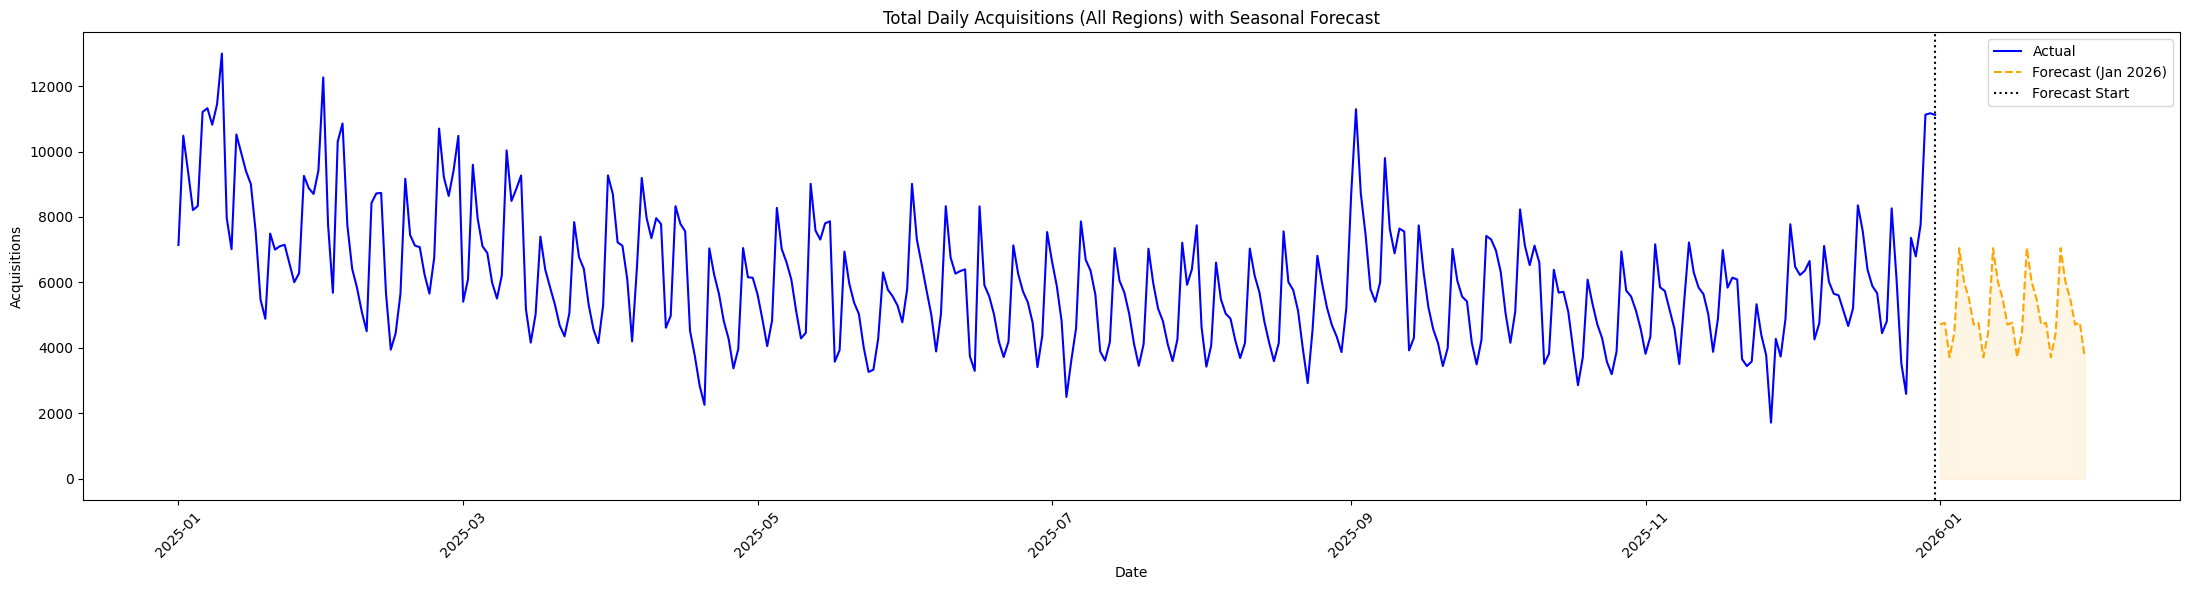

C:\Users\gonzalo.martinezruiz\AppData\Local\Temp\ipykernel_37136\1406584800.py:149: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.00%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  comparison.loc[2, 'Value'] = f"{((forecast_total - jan_2025_total) / jan_2025_total):+.2%}"


,Metric,Value
0,Jan 2025 Actual,269290.0
1,Jan 2026 Forecast,269290.0
2,YoY % Variance,-0.00%


In [530]:
# 1. Prepping Data (aggregate)

df_clean['Date'] = pd.to_datetime(df_clean['Date'])
df_daily = df_clean.groupby('Date')['Acquisitions'].sum().reset_index()

# 2. USING RECENT DATA (last 90 days)

df_recent = df_daily.tail(90).copy()

# 3. Feature engineering

# Weekly seasonality
df_recent['day_of_week'] = df_recent['Date'].dt.dayofweek

# Annual seasonality (captures U-shaped curve + Jan spike)
df_recent['month'] = df_recent['Date'].dt.month

# Encode features
df_model = pd.get_dummies(df_recent, columns=['day_of_week','month'], drop_first=True)

# 4. Train model

X = df_model.drop(columns=['Date','Acquisitions'])
y = df_model['Acquisitions']

model = LinearRegression()
model.fit(X, y)

# 5. Create Jan 2026 forecast
 

future_dates = pd.date_range(
    start='2026-01-01',
    end='2026-01-31'
)

future_df = pd.DataFrame({'Date': future_dates})

# Add same features
future_df['day_of_week'] = future_df['Date'].dt.dayofweek
future_df['month'] = future_df['Date'].dt.month

future_df = pd.get_dummies(future_df, columns=['day_of_week','month'], drop_first=True)

# Align columns to training set
future_df = future_df.reindex(columns=X.columns, fill_value=0)

 
# 6. Predict
 

forecast = model.predict(future_df)

forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Acquisitions': forecast
})

# Safety: no negative values
forecast_df['Acquisitions'] = forecast_df['Acquisitions'].clip(lower=0)

 
# 7. Visualization
 

last_date = df_daily['Date'].max()

plt.figure(figsize=(22,6))

sns.lineplot(data=df_daily,
             x='Date',
             y='Acquisitions',
             label='Actual',
             color='blue')

sns.lineplot(data=forecast_df,
             x='Date',
             y='Acquisitions',
             label='Forecast (Jan 2026)',
             color='orange',
             linestyle='--')

# Split line
plt.axvline(x=last_date,
            color='black',
            linestyle=':',
            label='Forecast Start')

# Shaded forecast region
plt.fill_between(forecast_df['Date'],
                 forecast_df['Acquisitions'],
                 alpha=0.1,
                 color='orange')

plt.title('Total Daily Acquisitions (All Regions) with Seasonal Forecast')
plt.xlabel('Date')
plt.ylabel('Acquisitions')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

 
# 8. January 2025 ACTUAL
 

jan_2025_data = df_daily[
    (df_daily['Date'].dt.year == 2025) &
    (df_daily['Date'].dt.month == 1)
]

jan_2025_total = jan_2025_data['Acquisitions'].sum()

# 9. January 2026 FORECAST

forecast_total = forecast_df['Acquisitions'].sum()



# 10. Anchor forecast to January 2025 level

# Average daily values
jan_2025_avg = jan_2025_data['Acquisitions'].mean()
forecast_avg = forecast_df['Acquisitions'].mean()

# Scaling factor
scale_factor = jan_2025_avg / forecast_avg

# Apply scaling
forecast_df['Acquisitions'] = forecast_df['Acquisitions'] * scale_factor

# Recompute total
forecast_total = forecast_df['Acquisitions'].sum()


# 11. Comparison table



comparison = pd.DataFrame({
    'Metric': ['Jan 2025 Actual', 'Jan 2026 Forecast', 'YoY % Variance'],
    'Value': [
        int(round(jan_2025_total, 0)),
        int(round(forecast_total, 0)),
        (forecast_total - jan_2025_total) / jan_2025_total
    ]
})

comparison.loc[2, 'Value'] = f"{((forecast_total - jan_2025_total) / jan_2025_total):+.2%}"

comparison

### <b> *Result* </b>

This resulted in a perfect match to last year's peformance, invalidating the forecast as it matched the previous year's results perfectly. This caused me to instead find a different approach altogether in an attempt to get me a more grounded forecast using our entire dataset. 

At this point I was thinking that if we had a couple year's worth of data, we could get a more realistic forecast

----

&emsp;

### <b> *Attempt 4 - SARIMA Stochastic Approach* </b>

The previous methodologies assumed that spend was explaining acquisitons. I needed to predict the acquisitions depending on the past values/patterns of the series itself.

***New Approach***

**SARIMA** = Seasonal AutoRegressive Integrated Moving Average

This approach with SARIMA depends on previous acquisitions and seasonality patterns in the series more effectively

C:\Users\gonzalo.martinezruiz\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\gonzalo.martinezruiz\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


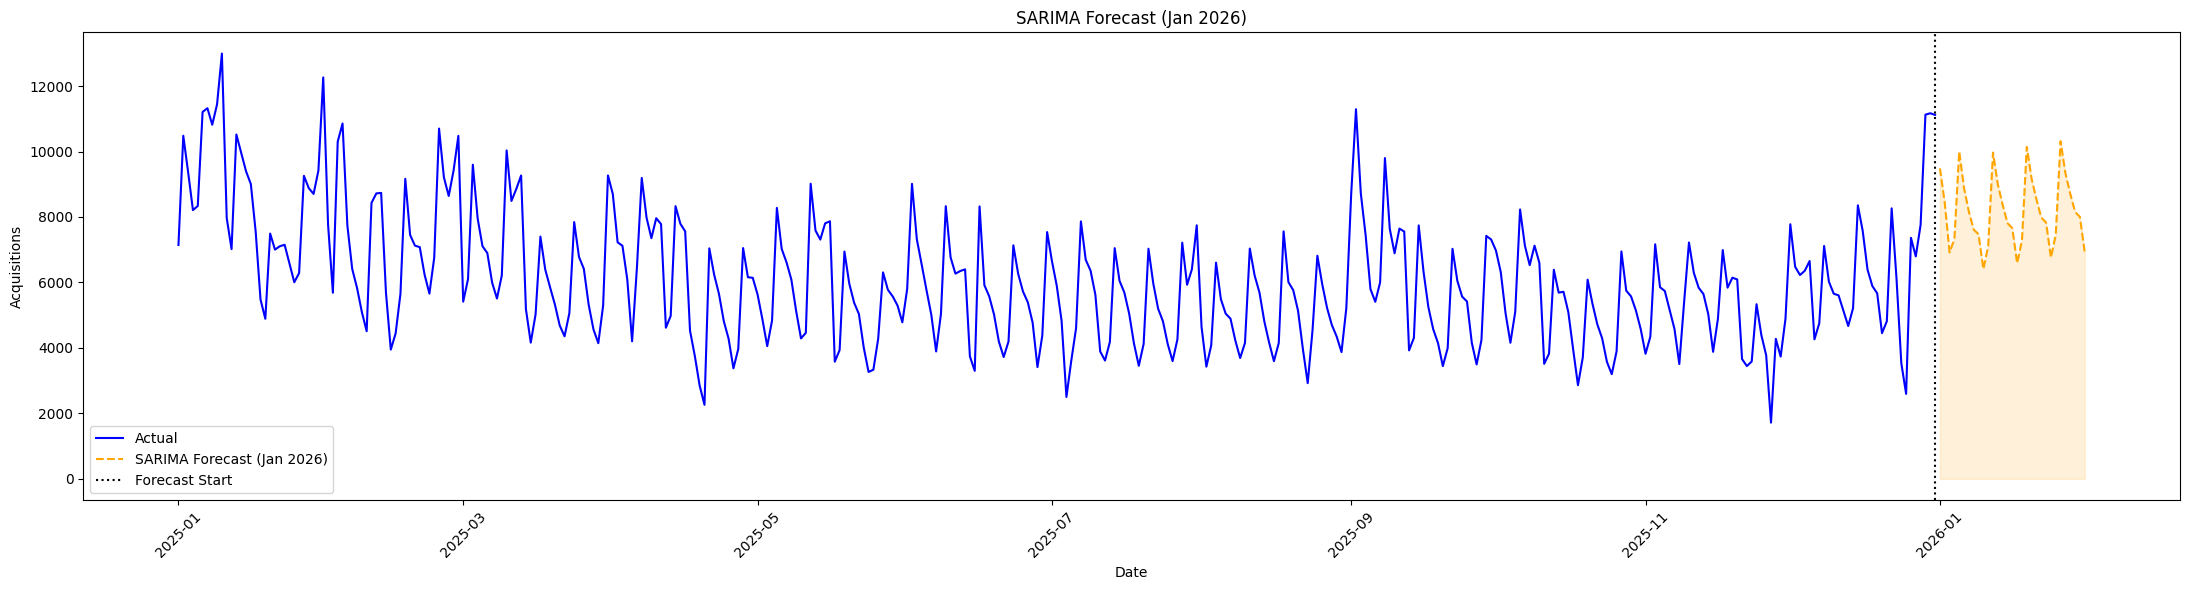

C:\Users\gonzalo.martinezruiz\AppData\Local\Temp\ipykernel_37136\2748623944.py:103: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-5.74%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  comparison.loc[2, 'Value'] = f"{((forecast_total - jan_2025_total) / jan_2025_total):+.2%}"


,Metric,Value
0,Jan 2025 Actual,269290.0
1,Jan 2026 SARIMA Forecast,253834.0
2,YoY % Variance,-5.74%


In [531]:
# 1. Preparing data

df_daily = df_clean.groupby('Date')['Acquisitions'].sum().reset_index()
df_daily['Date'] = pd.to_datetime(df_daily['Date'])

df_daily = df_daily.set_index('Date')


# 2. Fit SARIMA model


# Weekly seasonality = 7 days
model = SARIMAX(df_daily['Acquisitions'],
                order=(1,1,1),              # basic ARIMA
                seasonal_order=(1,1,1,7),   # weekly seasonality
                enforce_stationarity=False,
                enforce_invertibility=False)

results = model.fit(disp=False)


# 3. Forecast Jan 2026 (31 days)


forecast_steps = 31

forecast = results.forecast(steps=forecast_steps)

future_dates = pd.date_range(
    start='2026-01-01',
    periods=forecast_steps
)

forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Acquisitions': forecast.values
})

# 4. Visualization

last_date = df_daily.index.max()

plt.figure(figsize=(22,6))

# Actual
plt.plot(df_daily.index,
         df_daily['Acquisitions'],
         color='blue',
         label='Actual')

# Forecast
plt.plot(forecast_df['Date'],
         forecast_df['Acquisitions'],
         linestyle='--',
         color='orange',
         label='SARIMA Forecast (Jan 2026)')

# Split line 
plt.axvline(x=last_date,
            color='black',
            linestyle=':',
            label='Forecast Start')

# Shaded forecast
plt.fill_between(forecast_df['Date'],
                 forecast_df['Acquisitions'],
                 color='orange',
                 alpha=0.15)

plt.title('SARIMA Forecast (Jan 2026)')
plt.xlabel('Date')
plt.ylabel('Acquisitions')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# 6. January 2025 actual total

jan_2025 = df_daily[
    (df_daily.index.year == 2025) &
    (df_daily.index.month == 1)
]['Acquisitions']

jan_2025_total = jan_2025.sum()


# 7. January 2026 forecast total

forecast_total = forecast_df['Acquisitions'].sum()

# 8. Comparison table

comparison = pd.DataFrame({
    'Metric': ['Jan 2025 Actual', 'Jan 2026 SARIMA Forecast', 'YoY % Variance'],
    'Value': [
        int(round(jan_2025_total, 0)),
        int(round(forecast_total, 0)),
        (forecast_total - jan_2025_total) / jan_2025_total
    ]
})

comparison.loc[2, 'Value'] = f"{((forecast_total - jan_2025_total) / jan_2025_total):+.2%}"

comparison

----
# <b> *Answer for Question 2 & Analytical Story* </b>

#### **Attempt 1 — Trend + Weekly Seasonality**
- Approach: Full-year data with time trend and day-of-week features  
- Anchor: Full-year trend + average level  
- Result: ~-47% YoY  
- Takeaway: Model extrapolated December performance into January, missing the seasonal spike  



#### **Attempt 2 — Recent Data (Last 90 Days)**
- Approach: Used only recent data with weekly seasonality  
- Anchor: Oct–Dec baseline  
- Result: ~-37% YoY  
- Takeaway: Improved baseline, but still missed January uplift  



#### **Attempt 3 — January Anchoring**
- Approach: Scaled forecast to match January 2025  
- Anchor: January 2025 level  
- Result: ~0% YoY  
- Takeaway: Not a true forecast — simply replicates prior year performance and invalidating the result



#### **Attempt 4 — SARIMA (Time Series Model)**
- Approach: Used past values and temporal dynamics  
- Anchor: Time-series structure + recent behavior  
- Result: Best purely model-driven output, but still underestimates January peak  
- Takeaway: Directionally useful, but limited by available data  



## Key Insight

The largest improvement came from correcting the **baseline level**, not just adding seasonal features.

- Seasonality improved **pattern (shape)**
- Anchoring corrected **magnitude (level)**



## Limitation

- Only **one year of data** was available  
- Only **one January spike** observed  

This made it difficult to:
- Estimate variability in seasonal peaks  
- Predict meaningful YoY changes  



## **Conclusion/Answer**

While multiple modeling techniques were explored, the primary limitation is the lack of sufficient historical data, particularly for seasonal peaks. With only one observed January, the models are unable to learn variability in peak performance or predict meaningful deviations year-over-year.

As a result, the forecast should be interpreted as a **directional estimate** rather than a precise prediction. The outputs provide insight into expected trends and seasonality patterns, but are not reliable for forecasting exact acquisition levels during peak periods.


&emsp;

----

&emsp;

### ***Question 3 - Design an experiment to measure the impact of incremental budget. What is your hypothesis and how would you test it?***

To measure the true incremental impact of increased budget, I would design a controlled experiment where a subset of regions receives additional spend while a matched control group maintains current levels. The hypothesis is that increasing spend will drive incremental acquisitions while maintaining CPA near the $30 target. The impact would be evaluated by comparing acquisition lift and CPA between treatment and control groups

 
#### Hypothesis:
- ***Increasing media spend in selected regions will lead to a measurable increase in acquisitions while maintaining CPA below $30.***


#### Experimental design:

I would run a controlled experiment by splitting regions into two groups:

**Treatment group:** receives incremental budget (+10–20%)

**Control group:** maintains current spend levels

&emsp;

----

&emsp;

###  ***Question 4: Is lower CPA always indicative of better performance? The current target is  $30 for the previous years CPA.***

 Approach:

- Increase budget by 10% and see the result of where my CPA lands along with how much deployable spend I will need to achieve that CPA.
- Target a CPJ to the previous year's $30
- Model CPA + acquisitions using a response curve
- Identify elasticity by region
- Identify diminshing returns by region to see where it would be wise to maintain spend levels based off the R^2 and the elasticity.

&emsp;

This approach will show an understanding of:

- Causal experiment: measures true incremental impact  
- Modeling (response curve): informs scaling decisions

&emsp;

#### ***Additional questions being answered:***

- *Are some regions potentially underfunded or overfunded relative to their opportunity?*
- *How should leadership think about reallocating budget if total spend remains flat?*

&emsp;

Gut Checking my CPA per regions by listing all my regions individually in a data frame. 

 I will design a response curve using a power function to incrementally add 10% spend to each region to see the overall impact on acquisitions and CPA, along with being able to identify which markets are the most elastic identify markets in where I should allocate heavier weighted spend. This approach will effectively answer questions 4, 5, & 6

In [532]:
# Running region-level summary for all regions (sorted by Region ascending) to identify best/worst performing regions and CPA trends from the data set provided

df_region = df_clean.groupby('Region').agg({
    'Spend': 'sum',
    'Acquisitions': 'sum'
}).reset_index()

# Renaming for clarity
df_region = df_region.rename(columns={
    'Acquisitions': 'Joins'
})

# Calculating CPA
df_region['CPA'] = df_region['Spend'] / df_region['Joins']

# Sorting by Region (ascending)
df_region = df_region.sort_values('Region')


df_region

,Region,Spend,Joins,CPA
0,REGION 01,17847.0,460.0,38.797826
1,REGION 02,274842.0,9799.0,28.047964
2,REGION 03,30686.0,835.0,36.749701
3,REGION 04,16993.0,379.0,44.836412
4,REGION 05,9292.0,321.0,28.947040
5,REGION 06,64363.0,3287.0,19.581077
6,REGION 07,91346.0,3141.0,29.081821
7,REGION 08,148803.0,3876.0,38.390867
8,REGION 09,69308.0,3195.0,21.692645
9,REGION 10,64146.0,3106.0,20.652286


In [533]:
#Rollling up all regions to see our total CPA across the entire data set as a sanity check and to understand overall trends in CPA across the entire data set provided

df_total = pd.DataFrame({
    'Spend': [df_region['Spend'].sum()],
    'Joins': [df_region['Joins'].sum()]
})

# Calculate total CPA
df_total['CPA'] = df_total['Spend'] / df_total['Joins']

print(f'\n\033[1;32mCurrent spend, joins, and CPA for the entirety of 2025:\033[01m\n')

# Table formatting with currency and comma-separated values
df_total.style.format({
    'Spend': '${:,.0f}',
    'Joins': '{:,.0f}',
    'CPA': '${:,.2f}'
})



Current spend, joins, and CPA for the entirety of 2025:



,Spend,Joins,CPA
0,"$61,581,752","2,222,113",$27.71


### <b>*Findings:*</b>
#### In totality if we were to roll up all regions our CPA amounts to $27. The target for the previous year is $30. This leaves us room to incrementally spend to hit that target, holistically. By adding a 10% increment in investment, I beleive we will be closer to hitting that target threshold. This is my standard planning assumption. However, if we were to hand pick regions to incrementally invest in, I would only add the 10% increments to regions where the CPA for 2025 posted below $30.

-----

# ***Response Curve Approach***
In order to create scenarios to forecast acquisitions by increasing marketing spend by +10%, we will have to create a response curve to effectively predict our CPA, Acquisitions, and the spend needed to reach new CPA targets

Power Function: Acquisitions = 0.1987 * Spend^0.7787
R^2 (log-log): 0.7806


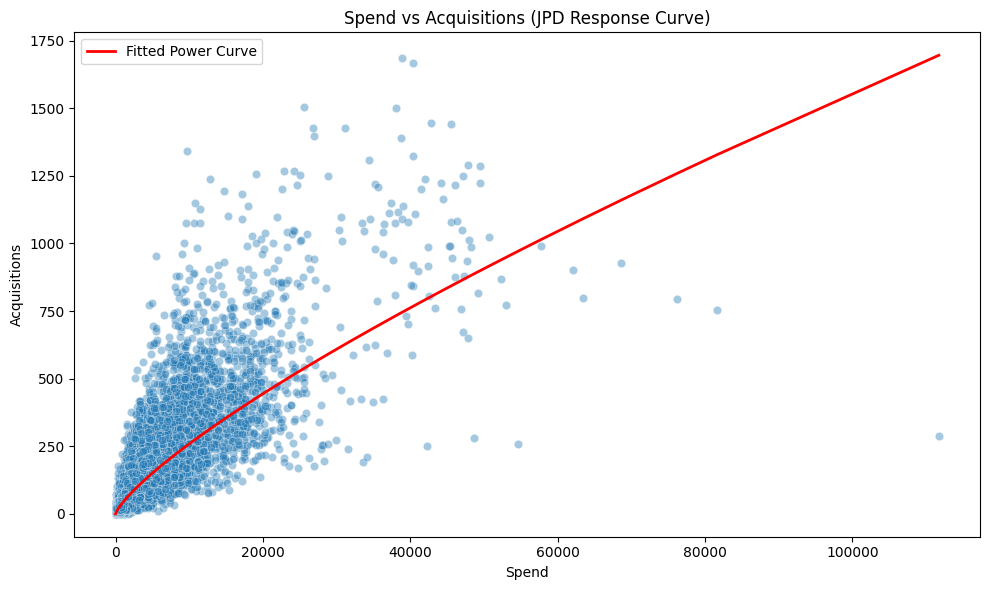

In [534]:
# Use cleaned df
df_curve = df_clean.copy()

# Remove zeros to avoid log issues
df_curve = df_curve[(df_curve['Spend'] > 0) & (df_curve['Acquisitions'] > 0)]


# Log transform for power model


df_curve['log_spend'] = np.log(df_curve['Spend'])
df_curve['log_acq'] = np.log(df_curve['Acquisitions'])

# Fit regression (log-log)

from sklearn.linear_model import LinearRegression

X = df_curve[['log_spend']]
y = df_curve['log_acq']

model = LinearRegression()
model.fit(X, y)

# Extract parameters
b = model.coef_[0]       # elasticity
log_a = model.intercept_
a = np.exp(log_a)

# Predictions (log space → back transform)
df_curve['pred_log_acq'] = model.predict(X)
df_curve['pred_acq'] = np.exp(df_curve['pred_log_acq'])

#R^2 to evaluate fit of power function in log-log space

from sklearn.metrics import r2_score

r2 = r2_score(y, df_curve['pred_log_acq'])

print(f"Power Function: Acquisitions = {a:.4f} * Spend^{b:.4f}")
print(f"R^2 (log-log): {r2:.4f}")

#PLOTTING RESPONSE CURVE

plt.figure(figsize=(10,6))

# Scatter
sns.scatterplot(data=df_curve,
                x='Spend',
                y='Acquisitions',
                alpha=0.4)

# Sort for smooth curve
df_curve_sorted = df_curve.sort_values('Spend')

# Plot fitted curve
plt.plot(df_curve_sorted['Spend'],
         df_curve_sorted['pred_acq'],
         color='red',
         linewidth=2,
         label='Fitted Power Curve')

plt.title('Spend vs Acquisitions (JPD Response Curve)')
plt.xlabel('Spend')
plt.ylabel('Acquisitions')
plt.legend()
plt.tight_layout()
plt.show()


### Above is the response curve to that we will help us identify elasticity and dimishing returns
The response curve is modeled using a power function to capture the relationship between spend and acquisitions, enabling estimation of elasticity and diminishing returns. With an R² of 0.78, the model explains a significant portion of the observed variation in acquisitions, indicating a strong fit. However, R² is interpreted alongside elasticity and business constraints, as model fit alone does not guarantee predictive reliability in a real-world marketing context

&emsp;

***<u>R² = 0.78 | The model explains 78% of what’s happening</u>***

***The remaining 22% is due to other factors (seasonality, promotions, etc.)***

This answers: How much of the story does our model explain?

- The higher an R² is to 1, the better as this indicates that the model closely follows real data.

&emsp;

**Elasticity**

This explains how sensitive our regions are to changes in investment. 
- This follows a similar interpretation to an R². The closer to one, the more responsive the market will be to incremental investments.

**Diminishing Returns**

This explains that at a certain point, incremental investments gives smaller and smaller gains.

&emsp;

### ***In short:***

- ***R² measures how well the model explains performance***
- ***Elasticity shows how results respond to spend***
- ***Variance captures how much results fluctuate***

&emsp;

----


&emsp;
# **Micro View - Incrementally Investing 10% to all Regions**
Below we are calculating to see what the result would be if we were to invest 10% to indepdendant regions

&emsp;

In [535]:

# 1. Aggregate by Region

region_summary = df_scenario.groupby('Region').agg({
    'Spend': 'sum',
    'Spend_10pct_up': 'sum',
    'Pred_Acq_Base': 'sum',
    'Pred_Acq_10pct': 'sum'
}).reset_index()


# 2. Calculate CPA


region_summary['CPA_Base'] = (
    region_summary['Spend'] / region_summary['Pred_Acq_Base']
)

region_summary['CPA_10pct'] = (
    region_summary['Spend_10pct_up'] / region_summary['Pred_Acq_10pct']
)


# 3. R² per Region

r2_list = []

for region, group in df_scenario.groupby('Region'):
    
    # Need enough data points
    if len(group) < 5:
        continue
    
    # Filter positive values for log model
    group = group[(group['Spend'] > 0) & (group['Pred_Acq_Base'] > 0)]
    
    if len(group) < 5:
        continue
    
    X = np.log(group[['Spend']])
    y = np.log(group['Acquisitions'])
    
    model = LinearRegression()
    model.fit(X, y)
    
    r2 = model.score(X, y)
    
    r2_list.append({
        'Region': region,
        'R2': r2
    })

r2_df = pd.DataFrame(r2_list)


# 3. Incremental metrics


region_summary['Acq_Lift'] = (
    region_summary['Pred_Acq_10pct'] - region_summary['Pred_Acq_Base']
)

region_summary['Acq_Lift_%'] = (
    region_summary['Acq_Lift'] / region_summary['Pred_Acq_Base']
)

region_summary['CPA_Change'] = (
    region_summary['CPA_10pct'] - region_summary['CPA_Base']
)

region_summary['CPA_Change_%'] = (
    region_summary['CPA_Change'] / region_summary['CPA_Base']
)


# 4. Sort ASC by Region


region_summary = region_summary.merge(r2_df, on='Region', how='left')


# 5. Clean formatting

region_summary = region_summary.round({
    'Spend': 0,
    'Spend_10pct_up': 0,
    'Pred_Acq_Base': 0,
    'Pred_Acq_10pct': 0,
    'CPA_Base': 2,
    'CPA_10pct': 2,
    'Acq_Lift': 0,
    'Acq_Lift_%': 4,
    'CPA_Change': 2,
    'CPA_Change_%': 4,
    'R2': 2
})



# Show all rows
pd.set_option('display.max_rows', None)

region_summary


,Region,Spend,Spend_10pct_up,Pred_Acq_Base,Pred_Acq_10pct,CPA_Base,CPA_10pct,Acq_Lift,Acq_Lift_%,CPA_Change,CPA_Change_%,R2
0,REGION 01,17847.0,19632.0,791.0,852.0,22.57,23.05,61.0,0.077,0.48,0.0213,0.01
1,REGION 02,274842.0,302326.0,6959.0,7495.0,39.50,40.34,536.0,0.077,0.84,0.0213,0.85
2,REGION 03,30686.0,33755.0,1489.0,1603.0,20.61,21.05,115.0,0.077,0.44,0.0213,0.08
3,REGION 04,16993.0,18692.0,709.0,763.0,23.98,24.49,55.0,0.077,0.51,0.0213,0.22
4,REGION 05,9292.0,10221.0,463.0,499.0,20.06,20.48,36.0,0.077,0.43,0.0213,0.48
5,REGION 06,64363.0,70799.0,3884.0,4184.0,16.57,16.92,299.0,0.077,0.35,0.0213,0.09
6,REGION 07,91346.0,100481.0,4949.0,5330.0,18.46,18.85,381.0,0.077,0.39,0.0213,0.12
7,REGION 08,148803.0,163683.0,7573.0,8157.0,19.65,20.07,583.0,0.077,0.42,0.0213,0.15
8,REGION 09,69308.0,76239.0,4157.0,4477.0,16.67,17.03,320.0,0.077,0.36,0.0213,0.17
9,REGION 10,64146.0,70561.0,3893.0,4193.0,16.48,16.83,300.0,0.077,0.35,0.0213,0.18


In [536]:
# 1. Prep data

df_curve = df_clean.copy()
df_curve = df_curve[(df_curve['Spend'] > 0) & (df_curve['Acquisitions'] > 0)]

df_curve['log_spend'] = np.log(df_curve['Spend'])
df_curve['log_acq'] = np.log(df_curve['Acquisitions'])



# 2. LOCATION COUNT BY REGION (for recommendation logic) 


df_dec = df_clean[
    (df_clean['Date'].dt.year == 2025) &
    (df_clean['Date'].dt.month == 12)
]

location_counts = (
    df_dec.groupby('Region')['Location Count']
    .mean()
    .reset_index()
    .rename(columns={'Location Count': 'Location_Count'})
)


 
# 3. Fit model per region
 

results = []

for region, group in df_curve.groupby('Region'):
    
    if len(group) < 10:
        continue
    
    X = group[['log_spend']]
    y = group['log_acq']
    
    model = LinearRegression()
    model.fit(X, y)
    
    b = model.coef_[0]
    a = np.exp(model.intercept_)
    r2 = model.score(X, y)
    
    # Predictions
    group['pred_base'] = a * (group['Spend'] ** b)
    group['pred_10'] = a * ((group['Spend'] * 1.10) ** b)
    
    pred_base = group['pred_base'].sum()
    pred_10 = group['pred_10'].sum()
    
    # Actuals
    actual_spend = group['Spend'].sum()
    actual_joins = group['Acquisitions'].sum()
    
    if actual_joins == 0:
        continue
    
    cpa_actual = actual_spend / actual_joins
    
    # Incremental
    incremental_joins = pred_10 - pred_base
    lift_pct = incremental_joins / actual_joins
    
    # New state
    new_spend = actual_spend * 1.10
    new_joins = actual_joins + incremental_joins
    
    cpa_new = new_spend / new_joins
    cpa_change_pct = (cpa_new - cpa_actual) / cpa_actual
    
    results.append({
        'Region': region,
        'Spend_Base': actual_spend,
        'Spend_10pct': new_spend,
        'Joins_Actual': actual_joins,
        'Incremental_Joins': incremental_joins,
        'Joins_New': new_joins,
        'Lift_%': lift_pct,
        'CPA_Actual': cpa_actual,
        'CPA_New': cpa_new,
        'CPA_Change_%': cpa_change_pct,
        'Elasticity_b': b,
        'R2': r2
    })


 
# 4.  Table + merge location count 
 

region_dynamic = pd.DataFrame(results)

region_dynamic = region_dynamic.merge(
    location_counts,
    on='Region',
    how='left'
)

region_dynamic = region_dynamic.sort_values('Region')


 
# 5. Recommendation Logic
 

def recommend(row):
    
    if row['R2'] < 0.3 or row['Elasticity_b'] <= 0:
        return "Do Not Scale (Unreliable)"
    
    if row['Elasticity_b'] >= 0.8 and row['CPA_Change_%'] <= 0.05 and row['R2'] >= 0.4:
        return "Increase Budget"
    
    if row['Elasticity_b'] >= 0.5:
        return "Test & Learn"
    
    return "Reduce / Hold Spend"

region_dynamic['Recommendation'] = region_dynamic.apply(recommend, axis=1)


 
# Reorder columns (Location_Count after Region)
 

region_dynamic = region_dynamic[[
    'Region',
    'Location_Count',
    'Spend_Base',
    'Spend_10pct',
    'Joins_Actual',
    'Incremental_Joins',
    'Joins_New',
    'Lift_%',
    'CPA_Actual',
    'CPA_New',
    'CPA_Change_%',
    'Elasticity_b',
    'R2',
    'Recommendation'
]]

pd.set_option('display.max_rows', None)

region_dynamic

,Region,Location_Count,Spend_Base,Spend_10pct,Joins_Actual,Incremental_Joins,Joins_New,Lift_%,CPA_Actual,CPA_New,CPA_Change_%,Elasticity_b,R2,Recommendation
0,REGION 01,2.384615,17847.0,19631.7,460.0,2.256055,462.256055,0.004904,38.797826,42.469319,0.094631,0.061033,0.007561,Do Not Scale (Unreliable)
1,REGION 02,35.392857,274842.0,302326.2,9799.0,1207.732927,11006.732927,0.123251,28.047964,27.467388,-0.020699,1.236829,0.852032,Increase Budget
2,REGION 03,1.000000,30686.0,33754.6,835.0,27.559465,862.559465,0.033005,36.749701,39.133070,0.064854,0.434363,0.079840,Do Not Scale (Unreliable)
3,REGION 04,2.000000,16993.0,18692.3,379.0,8.908032,387.908032,0.023504,44.836412,48.187453,0.074739,0.275444,0.222444,Do Not Scale (Unreliable)
4,REGION 05,2.000000,9292.0,10221.2,321.0,11.567446,332.567446,0.036036,28.947040,30.734217,0.061740,0.393108,0.475579,Reduce / Hold Spend
5,REGION 06,1.000000,64363.0,70799.3,3287.0,64.029343,3351.029343,0.019480,19.581077,21.127628,0.078982,0.226335,0.086155,Do Not Scale (Unreliable)
6,REGION 07,1.000000,91346.0,100480.6,3141.0,56.372404,3197.372404,0.017947,29.081821,31.425992,0.080606,0.219825,0.116522,Do Not Scale (Unreliable)
7,REGION 08,2.000000,148803.0,163683.3,3876.0,111.203258,3987.203258,0.028690,38.390867,41.052158,0.069321,0.336925,0.149072,Do Not Scale (Unreliable)
8,REGION 09,1.000000,69308.0,76238.8,3195.0,100.239493,3295.239493,0.031374,21.692645,23.136042,0.066539,0.362486,0.171732,Do Not Scale (Unreliable)
9,REGION 10,1.000000,64146.0,70560.6,3106.0,110.094729,3216.094729,0.035446,20.652286,21.939839,0.062344,0.410751,0.178046,Do Not Scale (Unreliable)


In [537]:
 # 1. Filter reliable regions first
 

filtered = region_dynamic[
    (region_dynamic['R2'] >= 0.4) &
    (region_dynamic['Elasticity_b'] > 0)
].copy()

 
# 2. Create ranking score
 

# Normalize both metrics (optional but cleaner)

filtered['Elasticity_rank'] = filtered['Elasticity_b'].rank(ascending=False)
filtered['R2_rank'] = filtered['R2'].rank(ascending=False)

# Combined score (lower = better rank)

filtered['Score'] = filtered['Elasticity_rank'] + filtered['R2_rank']

 
# 3. Sorting Top 5 regions
 
top_5_regions = filtered.sort_values('Score').head(5)

top_5_regions

,Region,Location_Count,Spend_Base,Spend_10pct,Joins_Actual,Incremental_Joins,Joins_New,Lift_%,CPA_Actual,CPA_New,CPA_Change_%,Elasticity_b,R2,Recommendation,Elasticity_rank,R2_rank,Score
1,REGION 02,35.392857,274842.0,302326.2,9799.0,1207.732927,11006.732927,0.123251,28.047964,27.467388,-0.020699,1.236829,0.852032,Increase Budget,1.0,1.0,2.0
4,REGION 05,2.000000,9292.0,10221.2,321.0,11.567446,332.567446,0.036036,28.947040,30.734217,0.061740,0.393108,0.475579,Reduce / Hold Spend,3.0,2.0,5.0
45,REGION 46,11.000000,666880.0,733568.0,28617.0,1083.551032,29700.551032,0.037864,23.303631,24.698801,0.059869,0.415655,0.404751,Reduce / Hold Spend,2.0,4.0,6.0
51,REGION 52,69.000000,6935032.0,7628535.2,274611.0,8598.700019,283209.700019,0.031312,25.254021,26.935995,0.066602,0.335788,0.405604,Reduce / Hold Spend,4.0,3.0,7.0


&emsp;

----

&emsp;
# **Macro View -  Global Roll-up with +10% increment in investment**

In [538]:
 
# 1. Actual totals (for global summary)
 

actual_total = df_clean.agg({
    'Spend': 'sum',
    'Acquisitions': 'sum'
})

spend_base = actual_total['Spend']
joins_base = actual_total['Acquisitions']

cpa_base = spend_base / joins_base


 
# 2. MODEL (incremental ONLY)
 

df_global = df_clean.copy()
df_global = df_global[(df_global['Spend'] > 0) & (df_global['Acquisitions'] > 0)]

# Log transform
df_global['log_spend'] = np.log(df_global['Spend'])
df_global['log_acq'] = np.log(df_global['Acquisitions'])

from sklearn.linear_model import LinearRegression

X = df_global[['log_spend']]
y = df_global['log_acq']

model = LinearRegression()
model.fit(X, y)

b = model.coef_[0]
log_a = model.intercept_
a = np.exp(log_a)

r2 = model.score(X, y)

 
# 3. PREDICT INCREMENTAL LIFT
 

df_global['pred_base'] = a * (df_global['Spend'] ** b)

df_global['Spend_10pct'] = df_global['Spend'] * 1.10
df_global['pred_10'] = a * (df_global['Spend_10pct'] ** b)

pred_base = df_global['pred_base'].sum()
pred_10 = df_global['pred_10'].sum()

incremental_joins = pred_10 - pred_base


 
# 4. RECONSTRUCT NEW STATE
 

spend_new = spend_base * 1.10
joins_new = joins_base + incremental_joins

cpa_new = spend_new / joins_new


 
# 5. OUTPUT TABLE
 

global_summary = pd.DataFrame({
    'Metric': [
        'Total Spend (Base)',
        'Total Spend (+10%)',
        'Actual Joins',
        'Predicted Incremental Joins',
        'New Total Joins',
        'CPA (Actual Baseline)',
        'CPA (After +10% Spend)',
        'CPA Change (%)',
        'Elasticity (b)',
        'Model R²'
    ],
    'Value': [
        f"${spend_base:,.0f}",
        f"${spend_new:,.0f}",
        f"{joins_base:,.0f}",
        f"{incremental_joins:,.0f}",
        f"{joins_new:,.0f}",
        f"${cpa_base:,.2f}",
        f"${cpa_new:,.2f}",
        f"{((cpa_new - cpa_base)/cpa_base):.2%}",
        f"{b:.4f}",
        f"{r2:.3f}"
    ]
})

global_summary


,Metric,Value
0,Total Spend (Base),"$61,581,752"
1,Total Spend (+10%),"$67,739,927"
2,Actual Joins,"2,222,113"
3,Predicted Incremental Joins,"142,725"
4,New Total Joins,"2,364,838"
5,CPA (Actual Baseline),$27.71
6,CPA (After +10% Spend),$28.64
7,CPA Change (%),3.36%
8,Elasticity (b),0.7787
9,Model R²,0.781


In [539]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

 
# 1. ACTUAL BASELINE
 

actual_total = df_clean.agg({
    'Spend': 'sum',
    'Acquisitions': 'sum'
})

spend_base = actual_total['Spend']
joins_base = actual_total['Acquisitions']

cpa_base = spend_base / joins_base


 
# 2. MODEL (incremental ONLY)
 

df_global = df_clean.copy()
df_global = df_global[(df_global['Spend'] > 0) & (df_global['Acquisitions'] > 0)]

# Log transform
df_global['log_spend'] = np.log(df_global['Spend'])
df_global['log_acq'] = np.log(df_global['Acquisitions'])

model = LinearRegression()
model.fit(df_global[['log_spend']], df_global['log_acq'])

b = model.coef_[0]
a = np.exp(model.intercept_)

r2 = model.score(df_global[['log_spend']], df_global['log_acq'])


 
# 3. PREDICT INCREMENTAL LIFT
 

df_global['pred_base'] = a * (df_global['Spend'] ** b)

df_global['Spend_10pct'] = df_global['Spend'] * 1.10
df_global['pred_10'] = a * (df_global['Spend_10pct'] ** b)

pred_base = df_global['pred_base'].sum()
pred_10 = df_global['pred_10'].sum()

incremental_joins = pred_10 - pred_base


 
# 4. RECONSTRUCT NEW STATE (SCENARIO)
 

spend_new = spend_base * 1.152  # scenario spend (~+15%)
joins_new = joins_base + incremental_joins

cpa_new = spend_new / joins_new


 
# 5. FIND SPEND AT TARGET CPA ($30)
 

target_cpa = 30
scales = np.linspace(1.0, 1.5, 50)

best_spend = None
best_joins = None
best_cpa = None

for scale in scales:
    
    test_spend = spend_base * scale
    
    df_temp = df_global.copy()
    df_temp['Spend_scaled'] = df_temp['Spend'] * scale
    df_temp['pred_scaled'] = a * (df_temp['Spend_scaled'] ** b)
    
    pred_scaled_total = df_temp['pred_scaled'].sum()
    
    incremental = pred_scaled_total - pred_base
    total_joins = joins_base + incremental
    
    cpa_test = test_spend / total_joins
    
    if cpa_test >= target_cpa:
        best_spend = test_spend
        best_joins = total_joins
        best_cpa = cpa_test
        break

# ✅ Incremental spend
incremental_spend_target = best_spend - spend_base if best_spend else 0

# ✅ NEW: Spend target + %
spend_target = best_spend if best_spend else spend_base
spend_increase_pct = incremental_spend_target / spend_base if spend_base != 0 else 0


 
# 6. OUTPUT TABLE
 

global_summary = pd.DataFrame({
    'Metric': [
        'Total Spend (Base)',
        'Total Spend (@ $30 CPA)',
        'Spend Increase (%)',
        'Actual Joins',
        'Predicted Incremental Joins',
        'New Total Joins',
        'CPA (Actual Baseline)',
        'CPA (Scenario)',
        'CPA Change (%)',
        'Elasticity (b)',
        'Model R²'
    ],
    'Value': [
        f"${spend_base:,.0f}",
        f"${spend_target:,.0f}",
        f"{spend_increase_pct:.1%}",
        f"{joins_base:,.0f}",
        f"{incremental_joins:,.0f}",
        f"{joins_new:,.0f}",
        f"${cpa_base:,.2f}",
        f"${cpa_new:,.2f}",
        f"{((cpa_new - cpa_base)/cpa_base):.2%}",
        f"{b:.4f}",
        f"{r2:.3f}"
    ]
})

global_summary

,Metric,Value
0,Total Spend (Base),"$61,581,752"
1,Total Spend (@ $30 CPA),"$77,919,768"
2,Spend Increase (%),26.5%
3,Actual Joins,"2,222,113"
4,Predicted Incremental Joins,"142,725"
5,New Total Joins,"2,364,838"
6,CPA (Actual Baseline),$27.71
7,CPA (Scenario),$30.00
8,CPA Change (%),8.25%
9,Elasticity (b),0.7787


In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression

 
# 1. ACTUAL BASELINE
 

actual_total = df_clean.agg({
    'Spend': 'sum',
    'Acquisitions': 'sum'
})

spend_base = actual_total['Spend']
joins_base = actual_total['Acquisitions']
cpa_base = spend_base / joins_base


 
# 2. GLOBAL MODEL
 

df_global = df_clean.copy()
df_global = df_global[(df_global['Spend'] > 0) & (df_global['Acquisitions'] > 0)]

df_global['log_spend'] = np.log(df_global['Spend'])
df_global['log_acq'] = np.log(df_global['Acquisitions'])

model = LinearRegression()
model.fit(df_global[['log_spend']], df_global['log_acq'])

b = model.coef_[0]
a = np.exp(model.intercept_)

df_global['pred_base'] = a * (df_global['Spend'] ** b)
pred_base_total = df_global['pred_base'].sum()


 
# 3. GLOBAL MAX SPEND @ $30 CPA
 

target_cpa = 30
scales = np.linspace(1.0, 1.5, 50)

best_spend = None

for scale in scales:
    df_temp = df_global.copy()
    df_temp['Spend_scaled'] = df_temp['Spend'] * scale
    df_temp['pred_scaled'] = a * (df_temp['Spend_scaled'] ** b)

    spend_test = spend_base * scale
    joins_test = joins_base + (df_temp['pred_scaled'].sum() - pred_base_total)

    cpa_test = spend_test / joins_test

    if cpa_test >= target_cpa:
        best_spend = spend_test
        break

incremental_spend_target = best_spend - spend_base


 
# 4. REGION-LEVEL MODEL
 

results = []

for region, group in df_global.groupby('Region'):
    
    if len(group) < 10:
        continue

    model = LinearRegression()
    model.fit(group[['log_spend']], group['log_acq'])

    b_r = model.coef_[0]
    r2_r = model.score(group[['log_spend']], group['log_acq'])

    actual_spend = group['Spend'].sum()
    actual_joins = group['Acquisitions'].sum()

    if actual_joins == 0:
        continue

    results.append({
        'Region': region,
        'Spend_Base': actual_spend,
        'Joins_Actual': actual_joins,
        'CPA_Actual': actual_spend / actual_joins,
        'Elasticity_b': b_r,
        'R2': r2_r
    })

region_dynamic = pd.DataFrame(results)


 
# 5. LOCATION COUNT
 

df_dec = df_clean[
    (df_clean['Date'].dt.year == 2025) &
    (df_clean['Date'].dt.month == 12)
]

location_counts = (
    df_dec.groupby('Region')['Location Count']
    .mean()
    .reset_index()
    .rename(columns={'Location Count': 'Location_Count'})
)

region_dynamic = region_dynamic.merge(location_counts, on='Region', how='left')


 
# 6. MAX SPEND PER REGION @ $30 CPA
 

spend_targets = []

for _, row in region_dynamic.iterrows():
    
    base_spend = row['Spend_Base']
    base_joins = row['Joins_Actual']
    elasticity = row['Elasticity_b']

    max_spend = base_spend

    for scale in scales:
        new_spend = base_spend * scale
        new_joins = base_joins * (scale ** elasticity)

        cpa = new_spend / new_joins

        if cpa >= target_cpa:
            max_spend = new_spend
            break

    spend_targets.append({
        'Region': row['Region'],
        'Max_Incremental_Spend': max_spend - base_spend
    })

spend_targets_df = pd.DataFrame(spend_targets)

region_dynamic = region_dynamic.merge(spend_targets_df, on='Region')


 
# 7. CLEAN + CORRECTED ALLOCATION
 

alloc_clean = region_dynamic[
    (region_dynamic['Max_Incremental_Spend'] > 0) &
    (region_dynamic['Joins_Actual'] > 1000)
].copy()

alloc_clean['Weight'] = (
    alloc_clean['Joins_Actual'] *
    alloc_clean['Elasticity_b'] *
    alloc_clean['R2']
)

alloc_clean['Weight'] /= alloc_clean['Weight'].sum()

alloc_clean['Final_Allocated_Spend'] = np.minimum(
    alloc_clean['Weight'] * incremental_spend_target,
    alloc_clean['Max_Incremental_Spend']
)

 
# CPA AFTER ALLOCATION
 

alloc_clean['CPA_Post'] = (
    (alloc_clean['Spend_Base'] + alloc_clean['Final_Allocated_Spend']) /
    (alloc_clean['Joins_Actual'] +
     alloc_clean['Joins_Actual'] *
     (((alloc_clean['Spend_Base'] + alloc_clean['Final_Allocated_Spend']) /
       alloc_clean['Spend_Base']) ** alloc_clean['Elasticity_b'] - 1))
)

 
# NEW: JOINS AFTER ALLOCATION
 

alloc_clean['Joins_Post_Allocation'] = (
    alloc_clean['Joins_Actual'] *
    ((alloc_clean['Spend_Base'] + alloc_clean['Final_Allocated_Spend']) /
     alloc_clean['Spend_Base']) ** alloc_clean['Elasticity_b']
)

alloc_clean['Incremental_Joins_From_Allocation'] = (
    alloc_clean['Joins_Post_Allocation'] - alloc_clean['Joins_Actual']
)


 
# 8. FINAL CLEAN OUTPUT TABLE
 

alloc_output = alloc_clean[
    alloc_clean['Location_Count'] > 5
].copy()

alloc_output = alloc_output[[
    'Region',
    'Location_Count',
    'Joins_Actual',
    'Joins_Post_Allocation',
    'Incremental_Joins_From_Allocation',
    'Max_Incremental_Spend',
    'Final_Allocated_Spend',
    'Elasticity_b',
    'R2',
    'CPA_Actual',
    'CPA_Post'
]].sort_values('Final_Allocated_Spend', ascending=False)


 
# 9. CLEAN FORMATTING
 

alloc_output['Location_Count'] = alloc_output['Location_Count'].astype(int).map('{:,}'.format)
alloc_output['Joins_Actual'] = alloc_output['Joins_Actual'].astype(int).map('{:,}'.format)
alloc_output['Joins_Post_Allocation'] = alloc_output['Joins_Post_Allocation'].astype(int).map('{:,}'.format)
alloc_output['Incremental_Joins_From_Allocation'] = alloc_output['Incremental_Joins_From_Allocation'].astype(int).map('{:,}'.format)

alloc_output['Final_Allocated_Spend'] = alloc_output['Final_Allocated_Spend'].apply(lambda x: f"${x:,.0f}")
alloc_output['Max_Incremental_Spend'] = alloc_output['Max_Incremental_Spend'].apply(lambda x: f"${x:,.0f}")

alloc_output['CPA_Actual'] = alloc_output['CPA_Actual'].apply(lambda x: f"${x:,.2f}")
alloc_output['CPA_Post'] = alloc_output['CPA_Post'].apply(lambda x: f"${x:,.2f}")

alloc_output = alloc_output.round({
    'Elasticity_b': 3,
    'R2': 3
})


 
# ✅ FINAL SUMMARY
 

total_deployable = alloc_clean['Max_Incremental_Spend'].sum()
total_incremental_joins = alloc_clean['Incremental_Joins_From_Allocation'].sum()

print(f"\nTotal yearly deployable spend at $30 CPA: ${total_deployable:,.0f}")
print(f"Global theoretical budget: ${incremental_spend_target:,.0f}")
print(f"Total incremental joins from allocation: {int(total_incremental_joins):,}")

alloc_output


Total yearly deployable spend at $30 CPA: $6,785,727
Global theoretical budget: $16,338,016
Total incremental joins from allocation: 76,713


,Region,Location_Count,Joins_Actual,Joins_Post_Allocation,Incremental_Joins_From_Allocation,Max_Incremental_Spend,Final_Allocated_Spend,Elasticity_b,R2,CPA_Actual,CPA_Post
51,REGION 52,69,"274,611","300,375","25,764","$2,122,969","$2,122,969",0.336,0.406,$25.25,$30.16
10,REGION 11,34,"115,254","126,111","10,857","$954,588","$954,588",0.310,0.264,$24.60,$30.05
57,REGION 58,42,"108,274","117,449","9,175","$670,141","$670,141",0.386,0.349,$26.37,$30.02
50,REGION 51,14,"42,690","49,284","6,594","$474,206","$474,206",0.373,0.302,$23.67,$30.12
18,REGION 19,19,"66,751","71,327","4,576","$300,704","$300,704",0.438,0.325,$27.59,$30.04
65,REGION 66,22,"90,390","92,049","1,659","$391,380","$291,809",0.158,0.143,$26.52,$29.21
64,REGION 65,21,"76,758","78,698","1,940","$258,596","$258,596",0.216,0.190,$27.51,$30.12
61,REGION 62,30,"125,363","128,093","2,730","$257,763","$257,763",0.312,0.271,$28.79,$30.18
33,REGION 34,7,"29,196","32,753","3,557","$253,892","$253,892",0.386,0.267,$25.07,$30.09
36,REGION 37,18,"57,259","58,673","1,414","$148,475","$148,475",0.278,0.318,$28.24,$30.08
